In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Predictive Maintenance.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: f

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


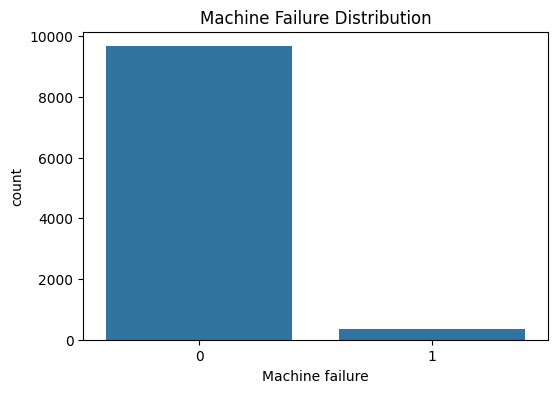

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Machine failure',data=df)
plt.title("Machine Failure Distribution")
plt.show()

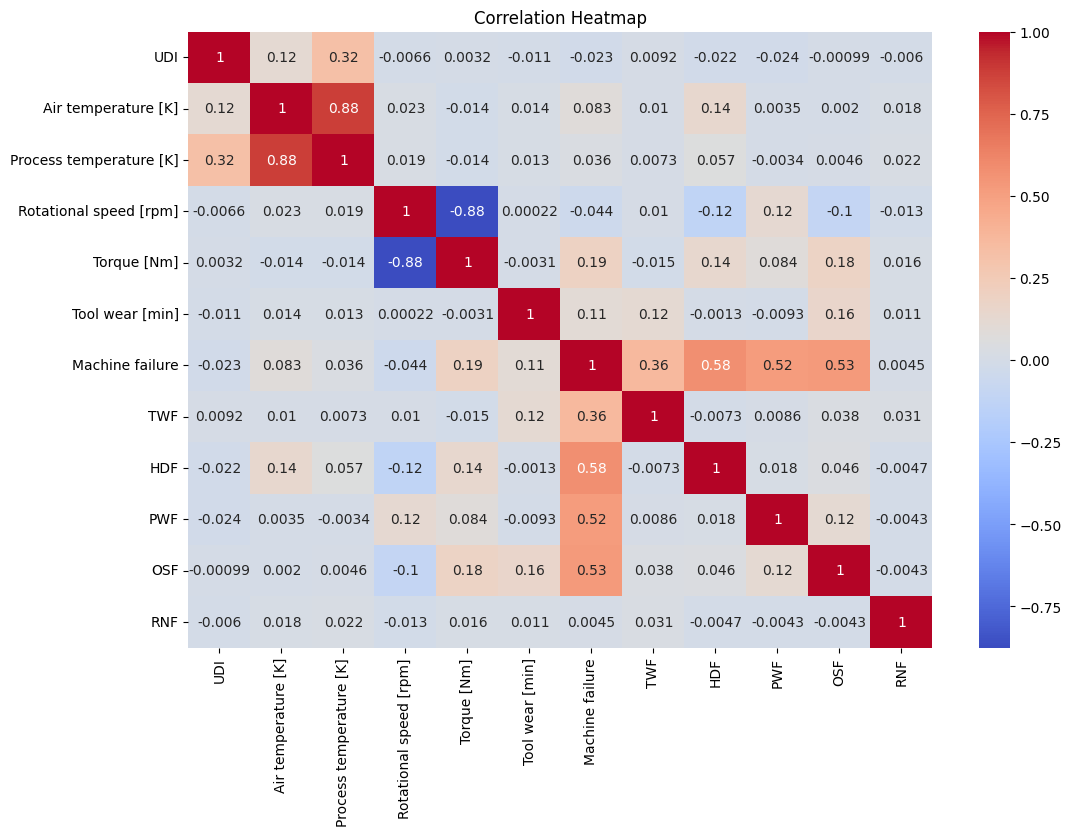

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [8]:
X = df[
['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']]

y = df['Machine failure']

In [9]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,stratify=y,random_state=42)
print(X_train.shape)
print(X_test.shape)

(8000, 5)
(2000, 5)


In [10]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)
print(y_train.value_counts())
print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE
Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [11]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote,y_train_smote)

LogisticRegression(max_iter=1000)

In [12]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_lr))
auc_lr = roc_auc_score(y_test,y_prob_lr)

print("Logistic Regression AUC:",auc_lr)

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000

Logistic Regression AUC: 0.9079664474485446


In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote,y_train_smote)

DecisionTreeClassifier(random_state=42)

In [15]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_dt))
auc_dt = roc_auc_score(y_test,y_prob_dt)

print("Logistic Regression AUC:",auc_dt)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.33      0.74      0.46        68

    accuracy                           0.94      2000
   macro avg       0.66      0.84      0.71      2000
weighted avg       0.97      0.94      0.95      2000

Logistic Regression AUC: 0.8417671416392644


In [18]:
from sklearn.svm import SVC
svm = SVC( probability=True,random_state=42)
svm.fit(X_train_smote,y_train_smote)

SVC(probability=True, random_state=42)

In [19]:
y_pred_svm = svm.predict(X_test)

y_prob_svm = svm.predict_proba(X_test)[:,1]

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_svm))
auc_svm = roc_auc_score(y_test,y_prob_svm)

print("SVM AUC:",auc_svm)

              precision    recall  f1-score   support

           0       1.00      0.79      0.88      1932
           1       0.13      0.90      0.23        68

    accuracy                           0.80      2000
   macro avg       0.56      0.84      0.56      2000
weighted avg       0.97      0.80      0.86      2000

SVM AUC: 0.9114297893070272


In [22]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier( n_estimators=100, random_state=42,class_weight='balanced')

rf.fit(X_train_smote,y_train_smote)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [23]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_rf))
auc_rf = roc_auc_score(y_test,y_prob_rf)

print("Random Forest AUC:",auc_rf)

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1932
           1       0.43      0.78      0.56        68

    accuracy                           0.96      2000
   macro avg       0.71      0.87      0.77      2000
weighted avg       0.97      0.96      0.96      2000

Random Forest AUC: 0.9636501339666301


In [26]:
results = pd.DataFrame({"Model":["Logistic Regression","Decision Tree","SVM","Random Forest"],

    "ROC-AUC":[auc_lr,auc_dt,auc_svm,auc_rf]
})

results

,Model,ROC-AUC
0,Logistic Regression,0.963650
1,Decision Tree,0.841767
2,SVM,0.911430
3,Random Forest,0.963650
